In [2]:
import sys
from pathlib import Path

# go from notebooks/ → project root
ROOT = Path.cwd().resolve().parent
sys.path.append(str(ROOT))

print("ROOT added to path:", ROOT)

ROOT added to path: /workspaces/Marketing-Decision-Engine-From-Attribution-to-Spend-Optimization


📥 Loading: /workspaces/Marketing-Decision-Engine-From-Attribution-to-Spend-Optimization/data/processed/clean.parquet
Shape: (50000, 55)
  channelGrouping      date        fullVisitorId  \
0  Organic Search  20160902  1131660440785968503   
1  Organic Search  20160902   377306020877927890   
2  Organic Search  20160902  3895546263509774583   
3  Organic Search  20160902  4763447161404445595   
4  Organic Search  20160902    27294437909732085   

                        sessionId  socialEngagementType     visitId  \
0  1131660440785968503_1472830385  Not Socially Engaged  1472830385   
1   377306020877927890_1472880147  Not Socially Engaged  1472880147   
2  3895546263509774583_1472865386  Not Socially Engaged  1472865386   
3  4763447161404445595_1472881213  Not Socially Engaged  1472881213   
4    27294437909732085_1472822600  Not Socially Engaged  1472822600   

   visitNumber      visitStartTime device_browser  \
0            1 2016-09-02 15:33:05         Chrome   
1            1 201

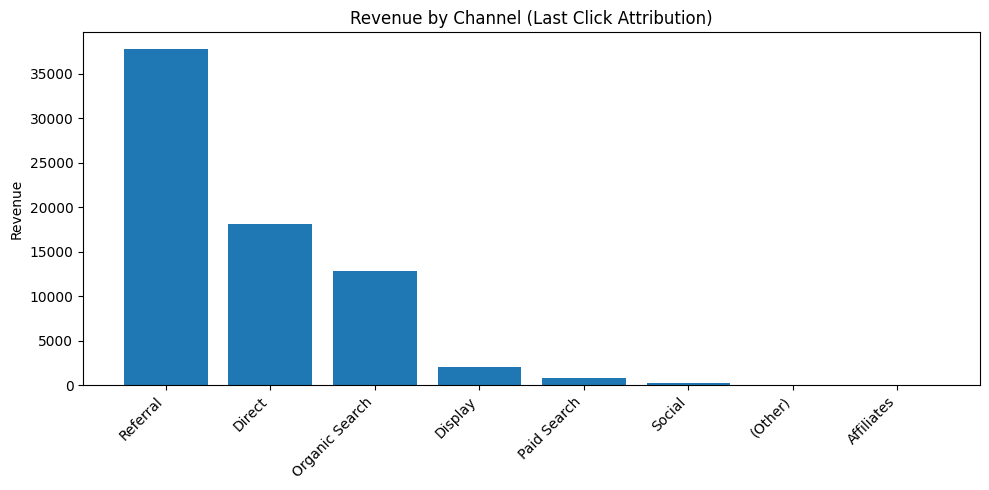

In [3]:
from src.data_loader import load_data
from src.attribution import last_click_attribution
import matplotlib.pyplot as plt


# ----------------------------
# 1. LOAD PREPROCESSED DATA
# ----------------------------
df = load_data("data/processed/clean.parquet")

print("Shape:", df.shape)
print(df.head())

# ----------------------------
# 2. BASIC EDA
# ----------------------------
print("\nData Summary:")
print(df.describe(include="all"))

print("\nMissing Values:")
print(df.isnull().sum())

# ----------------------------
# 3. ATTRIBUTION MODEL
# ----------------------------
attribution = last_click_attribution(df)

print("\nAttribution sample:")
print(attribution.head())

# ----------------------------
# 4. PLOT ATTRIBUTION
# ----------------------------
def plot_attribution(attribution):

    # Ensure aggregation (safe even if already aggregated)
    df_plot = attribution.copy()

    if 'channelGrouping' in df_plot.columns and 'revenue' in df_plot.columns:
        df_plot = df_plot.groupby('channelGrouping', as_index=False)['revenue'].sum()

    # Sort for clarity
    df_plot = df_plot.sort_values('revenue', ascending=False)

    plt.figure(figsize=(10, 5))
    plt.bar(df_plot['channelGrouping'], df_plot['revenue'])

    plt.xticks(rotation=45, ha='right')
    plt.title("Revenue by Channel (Last Click Attribution)")
    plt.ylabel("Revenue")

    plt.tight_layout()
    plt.show()

# Call plot
plot_attribution(attribution)

In [4]:
from src.preprocessing import save_to_excel

path = input("Enter output file path (e.g. outputs/data.xlsx): ")
# # Step 2: save cleaned data
cleaned_data = save_to_excel(df, path)

💾 Saved cleaned data to outputs/cleaned_data.xlsx


Data Sanity Checks

1.how much "not available in demo dataset" existed

2.duplicate sessions (visitId)

3.duplicate users (fullVisitorId)

In [5]:
na_counts = (df == "not available in demo dataset").sum().sort_values(ascending=False)
na_counts

device_mobileInputSelector                           50000
device_mobileDeviceInfo                              50000
device_mobileDeviceMarketingName                     50000
device_operatingSystemVersion                        50000
device_mobileDeviceBranding                          50000
device_browserVersion                                50000
device_browserSize                                   50000
device_flashVersion                                  50000
device_language                                      50000
device_screenColors                                  50000
device_screenResolution                              50000
device_mobileDeviceModel                             50000
geoNetwork_longitude                                 50000
geoNetwork_networkLocation                           50000
geoNetwork_cityId                                    50000
geoNetwork_latitude                                  50000
trafficSource_adwordsClickInfo.criteriaParameters    500

In [6]:
import importlib
import src.preprocessing as p
importlib.reload(p)

<module 'src.preprocessing' from '/workspaces/Marketing-Decision-Engine-From-Attribution-to-Spend-Optimization/src/preprocessing.py'>

In [7]:
from src.preprocessing import clean_placeholders, save_to_excel

path = input("Enter output file path (e.g. outputs/data.xlsx): ")

df_cleaned, dropped_cols = clean_placeholders(df)

# save_to_excel(df_cleaned, path)

🧹 Dropped 17 fully-placeholder columns
🧹 Replaced placeholder values with NaN


In [8]:
df_cleaned[df_cleaned.duplicated(subset=['sessionId'], keep=False)].head()

,channelGrouping,date,fullVisitorId,sessionId,socialEngagementType,visitId,visitNumber,visitStartTime,device_browser,device_operatingSystem,...,trafficSource_keyword,trafficSource_isTrueDirect,trafficSource_referralPath,trafficSource_adwordsClickInfo.page,trafficSource_adwordsClickInfo.slot,trafficSource_adwordsClickInfo.gclId,trafficSource_adwordsClickInfo.adNetworkType,trafficSource_adwordsClickInfo.isVideoAd,trafficSource_adContent,revenue


In [9]:
df_cleaned.groupby('visitId').size().sort_values(ascending=False).head()

visitId
1478942540    4
1498823774    4
1498823772    3
1479947582    3
1472821938    3
dtype: int64

In [10]:
df_session = df_cleaned.groupby('visitId').agg({
    'totals_pageviews': 'sum',
    'totals_hits': 'sum',
    'trafficSource_source': 'first'
}).reset_index()

In [11]:
df_session

,visitId,totals_pageviews,totals_hits,trafficSource_source
0,1470895819,2,2,mall.googleplex.com
1,1470898794,1,1,google
2,1470898819,1,1,youtube.com
3,1470898856,1,1,google
4,1470898928,1,1,(direct)
...,...,...,...,...
49041,1498892135,1,1,baidu
49042,1498892185,1,1,google
49043,1498892192,1,1,google
49044,1498892225,10,24,mall.googleplex.com


In [12]:
df_cleaned[df_cleaned.duplicated(subset=['fullVisitorId'], keep=False)].head()

,channelGrouping,date,fullVisitorId,sessionId,socialEngagementType,visitId,visitNumber,visitStartTime,device_browser,device_operatingSystem,...,trafficSource_keyword,trafficSource_isTrueDirect,trafficSource_referralPath,trafficSource_adwordsClickInfo.page,trafficSource_adwordsClickInfo.slot,trafficSource_adwordsClickInfo.gclId,trafficSource_adwordsClickInfo.adNetworkType,trafficSource_adwordsClickInfo.isVideoAd,trafficSource_adContent,revenue
47,Organic Search,20160902,3523749053085989464,3523749053085989464_1472825389,Not Socially Engaged,1472825389,1,2016-09-02 14:09:49,Chrome,Windows,...,(not provided),None,NaN,NaN,NaN,NaN,NaN,None,NaN,0.0
53,Organic Search,20160902,8720204952657722494,8720204952657722494_1472832336,Not Socially Engaged,1472832336,1,2016-09-02 16:05:36,Chrome,Windows,...,(not provided),None,NaN,NaN,NaN,NaN,NaN,None,NaN,0.0
63,Organic Search,20160902,0854783508496317255,0854783508496317255_1472823316,Not Socially Engaged,1472823316,5,2016-09-02 13:35:16,Chrome,Android,...,(not provided),True,NaN,NaN,NaN,NaN,NaN,None,NaN,0.0
67,Referral,20160902,3746051970600816343,3746051970600816343_1472843059,Not Socially Engaged,1472843059,2,2016-09-02 19:04:19,Chrome,Linux,...,NaN,None,/corp/google.com/study/incentives/working-with...,NaN,NaN,NaN,NaN,None,NaN,0.0
69,Organic Search,20160902,8720204952657722494,8720204952657722494_1472836503,Not Socially Engaged,1472836503,2,2016-09-02 17:15:03,Chrome,Windows,...,(not provided),True,NaN,NaN,NaN,NaN,NaN,None,NaN,0.0


In [13]:
df_cleaned.groupby('fullVisitorId')['visitId'].nunique().sort_values(ascending=False).head()

fullVisitorId
1957458976293878100    17
3269834865385146569    14
0232377434237234751    12
0824839726118485274    11
9801276214964695322    11
Name: visitId, dtype: int64

In [14]:
df_user = df_cleaned.groupby('fullVisitorId').agg({
    'visitId': 'nunique',
    'totals_pageviews': 'sum',
    'totals_hits': 'sum',
    'totals_transactionRevenue': 'sum',
    'channelGrouping': lambda x: x.mode()[0] if not x.mode().empty else None
}).reset_index()

df_user.rename(columns={'visitId': 'num_sessions'}, inplace=True)

In [15]:
df_user

,fullVisitorId,num_sessions,totals_pageviews,totals_hits,totals_transactionRevenue,channelGrouping
0,0000174067426171406,1,25,28,0.0,Organic Search
1,0000245437374675368,1,2,2,0.0,Social
2,0000750929315523353,1,1,1,0.0,Organic Search
3,0001156383977201253,1,1,1,0.0,Organic Search
4,0001213046045394417,1,1,1,0.0,Direct
...,...,...,...,...,...,...
45411,99980903580581121,1,4,5,0.0,Direct
45412,999889763383834152,2,87,87,0.0,Referral
45413,9999028091918322321,1,1,1,0.0,Social
45414,9999773079368714197,1,1,1,0.0,Organic Search


In [16]:
print("Unique users:", df_cleaned['fullVisitorId'].nunique())
print("Total rows:", len(df))

Unique users: 45416
Total rows: 50000


In [17]:
df_cleaned.groupby('fullVisitorId')['visitId'].nunique().describe()

count    45416.000000
mean         1.100934
std          0.429387
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: visitId, dtype: float64

In [18]:
repeat_users = df_cleaned.groupby('fullVisitorId')['visitId'].nunique()

print("Users with 1 session:", (repeat_users == 1).sum())
print("Users with >1 session:", (repeat_users > 1).sum())

Users with 1 session: 41979
Users with >1 session: 3437


In [19]:
df_cleaned['num_sessions_per_user'] = df.groupby('fullVisitorId')['visitId'].transform('nunique')

df_cleaned['is_returning_user'] = (df_cleaned['num_sessions_per_user'] > 1).astype(int)

In [20]:
df_cleaned[['fullVisitorId', 'visitId', 'num_sessions_per_user', 'is_returning_user']].head()

,fullVisitorId,visitId,num_sessions_per_user,is_returning_user
0,1131660440785968503,1472830385,1,0
1,377306020877927890,1472880147,1,0
2,3895546263509774583,1472865386,1,0
3,4763447161404445595,1472881213,1,0
4,27294437909732085,1472822600,1,0


Revenue distribution

How skewed is revenue?

Are most users non-buyers?

In [21]:
df_cleaned['totals_transactionRevenue'].describe()

count    5.000000e+04
mean     1.665590e+06
std      3.633017e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.498000e+09
Name: totals_transactionRevenue, dtype: float64

In [22]:
(df_cleaned['totals_transactionRevenue'] == 0).mean()

np.float64(0.98698)

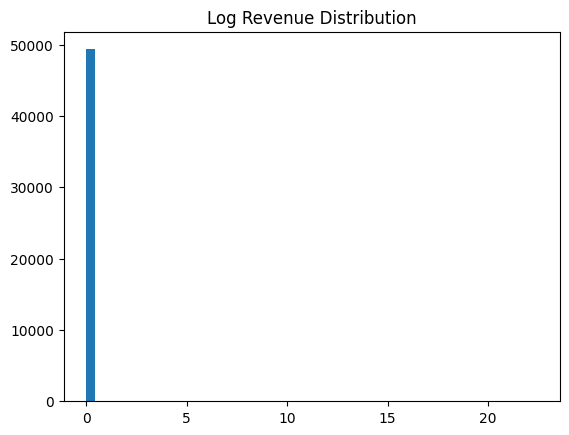

In [23]:
import numpy as np
import matplotlib.pyplot as plt

revenue = df_cleaned['totals_transactionRevenue']

plt.hist(np.log1p(revenue), bins=50)
plt.title("Log Revenue Distribution")
plt.show()

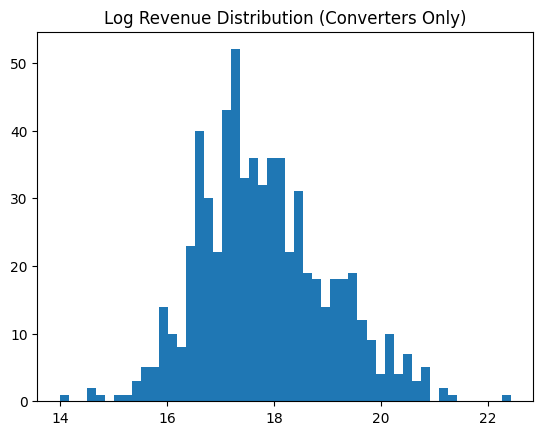

In [24]:
non_zero_revenue = df_cleaned[df_cleaned['totals_transactionRevenue'] > 0]['totals_transactionRevenue']

plt.hist(np.log1p(non_zero_revenue), bins=50)
plt.title("Log Revenue Distribution (Converters Only)")
plt.show()

In [25]:
revenue.skew()

np.float64(82.61665723441757)

In [26]:
df_sorted = df_cleaned.sort_values('totals_transactionRevenue', ascending=False)

top_10_pct = int(0.1 * len(df))
share_top_10 = df_sorted.head(top_10_pct)['totals_transactionRevenue'].sum() / df['totals_transactionRevenue'].sum()

print("Top 10% revenue share:", share_top_10)

Top 10% revenue share: 1.0


Conversion rate analysis

In [27]:
df_cleaned['converted'] = (df['totals_transactionRevenue'] > 0).astype(int)

In [28]:
df_conv = df_cleaned[df_cleaned['converted'] == 1]
import numpy as np
df_conv['log_revenue'] = np.log1p(df_conv['totals_transactionRevenue'])

In [29]:

conversion_rate = df_cleaned['converted'].mean()
print(f"Overall Conversion Rate: {conversion_rate:.4%}")

Overall Conversion Rate: 1.3020%


In [30]:
df_cleaned.groupby('channelGrouping')['converted'].mean().sort_values(ascending=False)

channelGrouping
Referral          0.054866
Display           0.023136
Direct            0.015192
Paid Search       0.014157
Organic Search    0.007903
Social            0.000641
(Other)           0.000000
Affiliates        0.000000
Name: converted, dtype: float64

In [31]:
df_cleaned.groupby('device_deviceCategory')['converted'].mean()

device_deviceCategory
desktop    0.016181
mobile     0.004420
tablet     0.004245
Name: converted, dtype: float64

In [32]:
df_cleaned.groupby('is_returning_user')['converted'].mean()

is_returning_user
0    0.009481
1    0.031542
Name: converted, dtype: float64

In [33]:
df_cleaned.groupby('num_sessions_per_user')['converted'].mean().head(10)

num_sessions_per_user
1     0.009481
2     0.032004
3     0.035386
4     0.028986
5     0.017778
6     0.014493
7     0.035714
8     0.000000
9     0.055556
10    0.000000
Name: converted, dtype: float64

<Axes: ylabel='channelGrouping'>

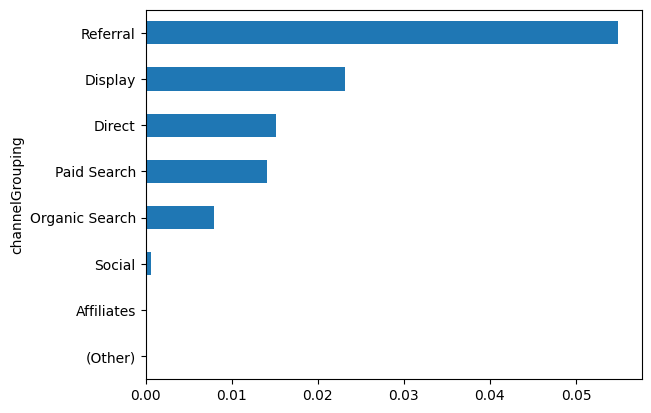

In [34]:
df_cleaned.groupby('channelGrouping')['converted'].mean().sort_values().plot(kind='barh')

In [35]:
df_cleaned['expected_revenue'] = df_cleaned['converted'] * df_cleaned['totals_transactionRevenue']

df_cleaned.groupby('channelGrouping')['expected_revenue'].mean()

channelGrouping
(Other)           0.000000e+00
Affiliates        0.000000e+00
Direct            2.680899e+06
Display           5.873573e+06
Organic Search    7.424960e+05
Paid Search       6.674646e+05
Referral          7.211802e+06
Social            2.384535e+04
Name: expected_revenue, dtype: float64

In [36]:
conv_by_channel = df_cleaned.groupby('channelGrouping')['converted'].mean()

traffic_share = df_cleaned['channelGrouping'].value_counts(normalize=True)

summary = df_cleaned.groupby('channelGrouping').agg({
    'converted': 'mean',
    'fullVisitorId': 'count',
    'totals_transactionRevenue': 'sum'
}).rename(columns={
    'converted': 'conversion_rate',
    'fullVisitorId': 'traffic',
    'totals_transactionRevenue': 'revenue'
})

summary['traffic_share'] = summary['traffic'] / len(df)

summary.sort_values('conversion_rate', ascending=False)



,conversion_rate,traffic,revenue,traffic_share
channelGrouping,,,,
Referral,0.054866,5960,4.298234e+10,0.11920
Display,0.023136,389,2.284820e+09,0.00778
Direct,0.015192,7899,2.117642e+10,0.15798
Paid Search,0.014157,1554,1.037240e+09,0.03108
Organic Search,0.007903,20877,1.550109e+10,0.41754
Social,0.000641,12480,2.975900e+08,0.24960
(Other),0.000000,1,0.000000e+00,0.00002
Affiliates,0.000000,840,0.000000e+00,0.01680


Traffic source performance

In [37]:

summary['revenue_per_session'] = summary['revenue'] / summary['traffic']

summary = summary.sort_values('revenue', ascending=False)

summary

,conversion_rate,traffic,revenue,traffic_share,revenue_per_session
channelGrouping,,,,,
Referral,0.054866,5960,4.298234e+10,0.11920,7.211802e+06
Direct,0.015192,7899,2.117642e+10,0.15798,2.680899e+06
Organic Search,0.007903,20877,1.550109e+10,0.41754,7.424960e+05
Display,0.023136,389,2.284820e+09,0.00778,5.873573e+06
Paid Search,0.014157,1554,1.037240e+09,0.03108,6.674646e+05
Social,0.000641,12480,2.975900e+08,0.24960,2.384535e+04
(Other),0.000000,1,0.000000e+00,0.00002,0.000000e+00
Affiliates,0.000000,840,0.000000e+00,0.01680,0.000000e+00


In [38]:
summary['expected_revenue_per_session'] = summary['revenue'] / summary['traffic']

In [39]:
summary['revenue_per_session']

channelGrouping
Referral          7.211802e+06
Direct            2.680899e+06
Organic Search    7.424960e+05
Display           5.873573e+06
Paid Search       6.674646e+05
Social            2.384535e+04
(Other)           0.000000e+00
Affiliates        0.000000e+00
Name: revenue_per_session, dtype: float64

<Axes: title={'center': 'Conversion Rate by Channel'}, ylabel='channelGrouping'>

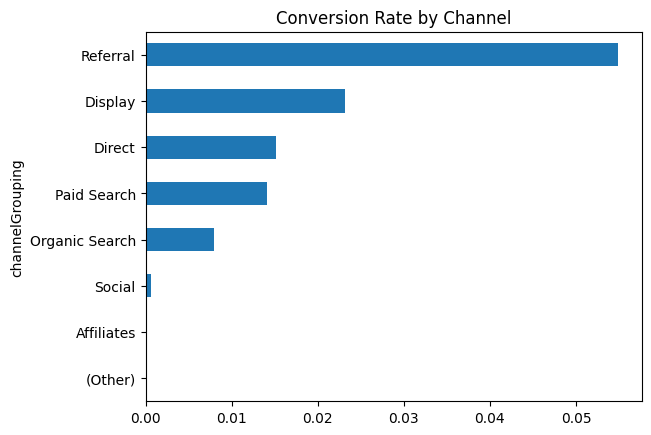

In [40]:
summary.sort_values('conversion_rate')['conversion_rate'].plot(kind='barh', title='Conversion Rate by Channel')

Device behavior analysis

Mobile vs desktop conversion?

OS differences?

In [41]:
device_summary = df_cleaned.groupby('device_deviceCategory').agg({
    'converted': 'mean',
    'fullVisitorId': 'count',
    'totals_transactionRevenue': 'sum'
}).rename(columns={
    'converted': 'conversion_rate',
    'fullVisitorId': 'traffic',
    'totals_transactionRevenue': 'revenue'
})

device_summary['traffic_share'] = device_summary['traffic'] / len(df)
device_summary['revenue_per_session'] = (
    device_summary['revenue'] / device_summary['traffic']
)

device_summary.sort_values('conversion_rate', ascending=False)

,conversion_rate,traffic,revenue,traffic_share,revenue_per_session
device_deviceCategory,,,,,
desktop,0.016181,36585,7.921439e+10,0.73170,2.165215e+06
mobile,0.004420,11766,3.900380e+09,0.23532,3.314958e+05
tablet,0.004245,1649,1.647300e+08,0.03298,9.989691e+04


In [42]:
os_summary = df_cleaned.groupby('device_operatingSystem').agg({
    'converted': 'mean',
    'fullVisitorId': 'count',
    'totals_transactionRevenue': 'sum'
}).rename(columns={
    'converted': 'conversion_rate',
    'fullVisitorId': 'traffic',
    'totals_transactionRevenue': 'revenue'
})

os_summary['revenue_per_session'] = (
    os_summary['revenue'] / os_summary['traffic']
)

os_summary.sort_values('conversion_rate', ascending=False).head(10)

,conversion_rate,traffic,revenue,revenue_per_session
device_operatingSystem,,,,
Chrome OS,0.040856,1542,9.105650e+09,5.905091e+06
Linux,0.025880,1932,2.461090e+09,1.273856e+06
Macintosh,0.024698,14171,4.878248e+10,3.442416e+06
Windows Phone,0.012821,78,2.640000e+07,3.384615e+05
Windows,0.006845,18992,1.889315e+10,9.947952e+05
iOS,0.004502,6219,9.073800e+08,1.459045e+05
Android,0.004267,6796,3.103350e+09,4.566436e+05
Firefox OS,0.000000,5,0.000000e+00,0.000000e+00
BlackBerry,0.000000,17,0.000000e+00,0.000000e+00


<Axes: title={'center': 'Conversion Rate by Device'}, ylabel='device_deviceCategory'>

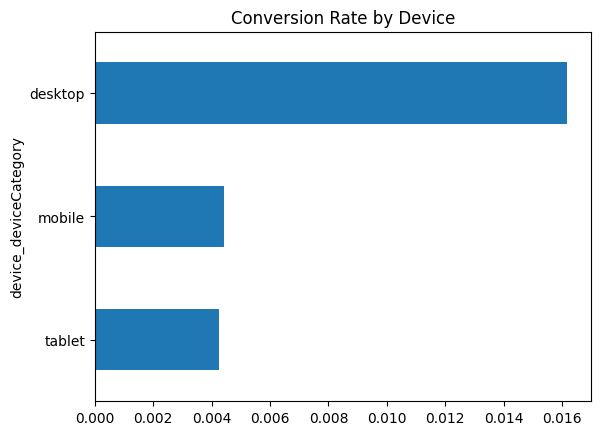

In [43]:
device_summary['conversion_rate'].sort_values().plot(
    kind='barh',
    title='Conversion Rate by Device'
)

<Axes: title={'center': 'Top OS by Conversion Rate'}, ylabel='device_operatingSystem'>

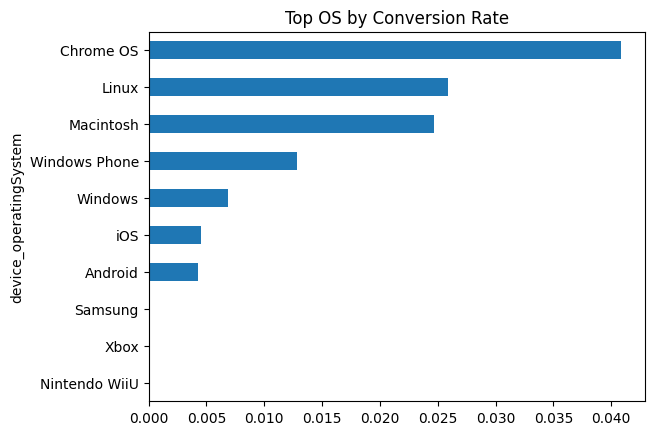

In [44]:
os_summary['conversion_rate'].sort_values().tail(10).plot(
    kind='barh',
    title='Top OS by Conversion Rate'
)

Geography insights

country-level revenue

city-level conversion rate

In [45]:
country_summary = df_cleaned.groupby('geoNetwork_country').agg({
    'totals_transactionRevenue': 'sum',
    'fullVisitorId': 'count',
    'converted': 'mean'
}).rename(columns={
    'totals_transactionRevenue': 'revenue',
    'fullVisitorId': 'traffic',
    'converted': 'conversion_rate'
})

country_summary['revenue_per_session'] = (
    country_summary['revenue'] / country_summary['traffic']
)

country_summary = country_summary.sort_values('revenue', ascending=False)

country_summary.head(10)

,revenue,traffic,conversion_rate,revenue_per_session
geoNetwork_country,,,,
United States,8.220326e+10,19980,0.031582,4.114277e+06
Canada,2.976400e+08,1341,0.005220,2.219538e+05
Taiwan,2.423900e+08,581,0.003442,4.171945e+05
Mexico,1.801600e+08,771,0.002594,2.336706e+05
Switzerland,9.449000e+07,199,0.005025,4.748241e+05
Germany,6.898000e+07,1046,0.000956,6.594646e+04
New Zealand,4.797000e+07,101,0.009901,4.749505e+05
Israel,4.707000e+07,284,0.003521,1.657394e+05
Ireland,3.359000e+07,340,0.002941,9.879412e+04


In [46]:
city_summary = df_cleaned.groupby('geoNetwork_city').agg({
    'converted': 'mean',
    'fullVisitorId': 'count'
}).rename(columns={
    'converted': 'conversion_rate',
    'fullVisitorId': 'traffic'
})

# Filter meaningful cities (important)
city_summary = city_summary[city_summary['traffic'] > 100]

city_summary.sort_values('conversion_rate', ascending=False).head(10)

,conversion_rate,traffic
geoNetwork_city,,
Ann Arbor,0.085271,129
Austin,0.075581,172
Seattle,0.071429,294
Kirkland,0.069307,101
New York,0.068794,1410
Chicago,0.057789,398
Salem,0.044118,136
San Francisco,0.039417,1167
Mountain View,0.031962,2503


<Axes: title={'center': 'Top Countries by Revenue'}, ylabel='geoNetwork_country'>

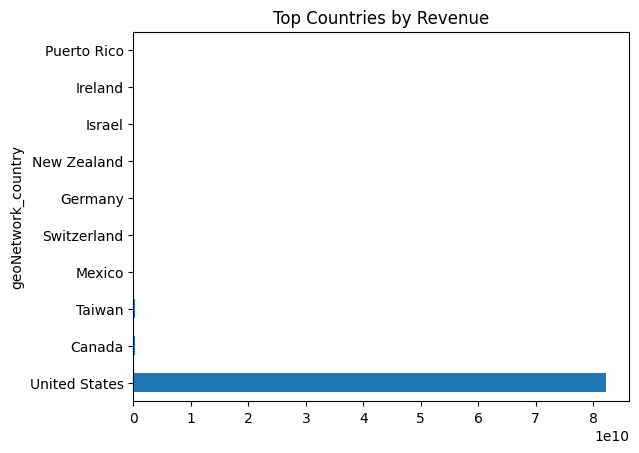

In [47]:
country_summary.head(10)['revenue'].plot(
    kind='barh',
    title='Top Countries by Revenue'
)

In [48]:
country_summary['revenue_share'] = (
    country_summary['revenue'] / country_summary['revenue'].sum()
)

country_summary['cumulative_share'] = country_summary['revenue_share'].cumsum()

In [49]:
country_summary.head(10)


,revenue,traffic,conversion_rate,revenue_per_session,revenue_share,cumulative_share
geoNetwork_country,,,,,,
United States,8.220326e+10,19980,0.031582,4.114277e+06,0.987077,0.987077
Canada,2.976400e+08,1341,0.005220,2.219538e+05,0.003574,0.990651
Taiwan,2.423900e+08,581,0.003442,4.171945e+05,0.002911,0.993561
Mexico,1.801600e+08,771,0.002594,2.336706e+05,0.002163,0.995725
Switzerland,9.449000e+07,199,0.005025,4.748241e+05,0.001135,0.996859
Germany,6.898000e+07,1046,0.000956,6.594646e+04,0.000828,0.997688
New Zealand,4.797000e+07,101,0.009901,4.749505e+05,0.000576,0.998264
Israel,4.707000e+07,284,0.003521,1.657394e+05,0.000565,0.998829
Ireland,3.359000e+07,340,0.002941,9.879412e+04,0.000403,0.999232


In [50]:
city_summary.head(10)

,conversion_rate,traffic
geoNetwork_city,,
Amsterdam,0.000000,160
Ann Arbor,0.085271,129
Atlanta,0.029851,134
Austin,0.075581,172
Bangkok,0.000000,457
Bengaluru,0.000000,288
Bucharest,0.000000,177
Chennai,0.000000,226
Chicago,0.057789,398


Time-based patterns

Do weekends convert more?

Time-of-day effects?

In [51]:
import pandas as pd

df_cleaned['date'] = pd.to_datetime(df['date'], format='%Y%m%d')  # adjust if needed
df_cleaned['day_of_week'] = df_cleaned['date'].dt.day_name()
df_cleaned['is_weekend'] = df_cleaned['day_of_week'].isin(['Saturday', 'Sunday'])

In [52]:
df_cleaned.groupby('is_weekend')['converted'].mean()

is_weekend
False    0.014112
True     0.006884
Name: converted, dtype: float64

In [53]:
df_cleaned['is_weekend'].value_counts(normalize=True)

is_weekend
False    0.84892
True     0.15108
Name: proportion, dtype: float64

<Axes: title={'center': 'Conversion Rate by Day'}, xlabel='day_of_week'>

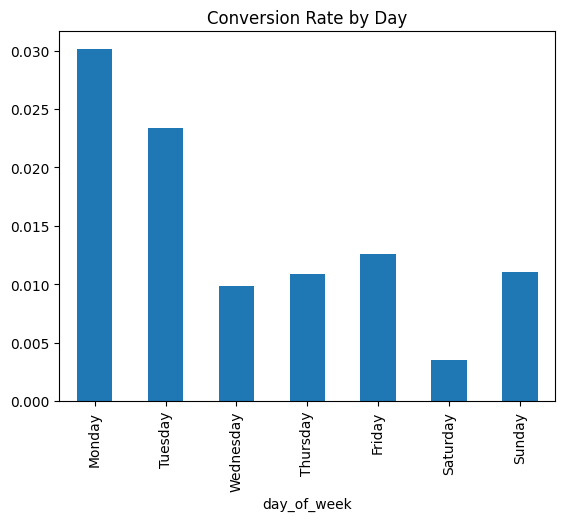

In [54]:
df_cleaned.groupby('day_of_week')['converted'].mean().loc[
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
].plot(kind='bar', title='Conversion Rate by Day')

In [55]:
df_cleaned['hour'] = pd.to_datetime(df_cleaned['visitStartTime'], unit='s').dt.hour

In [56]:
hourly_conv = df_cleaned.groupby('hour')['converted'].mean()
hourly_conv

hour
0     0.018161
1     0.009867
2     0.018430
3     0.012550
4     0.013166
5     0.013816
6     0.005131
7     0.002435
8     0.000601
9     0.003628
10    0.002335
11    0.001118
12    0.003586
13    0.006441
14    0.012282
15    0.018994
16    0.017696
17    0.020073
18    0.015251
19    0.016980
20    0.019761
21    0.024058
22    0.016430
23    0.017682
Name: converted, dtype: float64

<Axes: title={'center': 'Conversion Rate by Hour'}, xlabel='hour'>

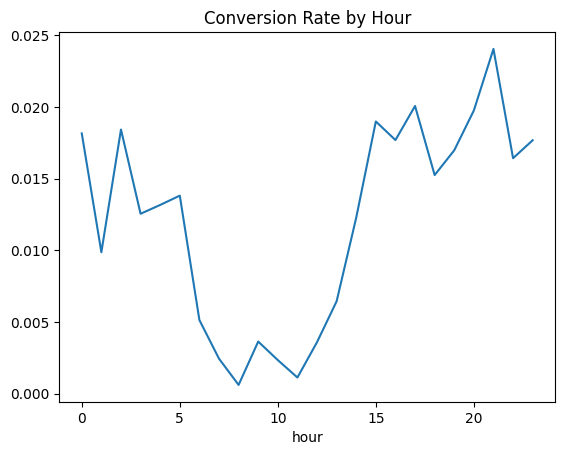

In [57]:
hourly_conv.plot(title='Conversion Rate by Hour')

In [58]:
pivot = df_cleaned.pivot_table(
    values='converted',
    index='day_of_week',
    columns='hour',
    aggfunc='mean'
)

pivot

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Friday,0.012924,0.007260,0.015957,0.010399,0.009940,0.015453,0.006565,0.003503,0.000000,0.003515,...,0.009313,0.019958,0.016129,0.020106,0.016113,0.018962,0.020788,0.024419,0.015748,0.013280
Monday,0.049383,0.024390,0.000000,0.015873,0.037975,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.052632,0.067114,0.057971,0.070513,0.028169,0.031496,0.032258,0.027027,0.007576,0.038462
Saturday,0.016000,0.000000,0.013699,0.000000,0.007092,0.013514,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.005208,0.004878,0.004717,0.005128,0.005319,0.005155,0.000000,0.006897
Sunday,0.039216,0.013333,0.015504,0.006329,0.007692,0.000000,0.000000,0.014286,0.000000,0.014286,...,0.000000,0.000000,0.005882,0.025000,0.020000,0.019231,0.005988,0.011834,0.025478,0.007937
Thursday,0.020906,0.015810,0.006944,0.007018,0.010135,0.009174,0.007246,0.000000,0.000000,0.003322,...,0.004494,0.017787,0.010799,0.009901,0.013400,0.008602,0.017621,0.031553,0.023810,0.028037
Tuesday,0.009346,0.020000,0.071823,0.034146,0.028249,0.037975,0.005714,0.005848,0.005435,0.006250,...,0.027682,0.023529,0.043189,0.028662,0.027027,0.026059,0.033088,0.039286,0.011278,0.020576
Wednesday,0.014134,0.003030,0.010490,0.015528,0.011152,0.010989,0.006173,0.000000,0.000000,0.000000,...,0.009412,0.015909,0.008658,0.013187,0.006742,0.015317,0.015945,0.017766,0.019718,0.017442


In [59]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pivot = pivot.reindex(day_order)

In [60]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    pivot,
    cmap='YlGnBu',
    annot=False
)

plt.title("Conversion Heatmap (Ordered Days)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

NameError: name 'sns' is not defined

<Figure size 1400x600 with 0 Axes>

In [61]:
df_cleaned['is_peak_hour'] = df_cleaned['hour'].between(18, 22).astype(int)

Funnel behavior

In [62]:
df_cleaned['totals_pageviews'] = pd.to_numeric(df_cleaned['totals_pageviews'], errors='coerce')
df_cleaned['totals_hits'] = pd.to_numeric(df_cleaned['totals_hits'], errors='coerce')
df_cleaned['totals_transactionRevenue'] = pd.to_numeric(
    df['totals_transactionRevenue'], errors='coerce'
)

In [63]:
funnel = {}

# Stage 1: total sessions
funnel['sessions'] = len(df_cleaned)

# Stage 2: engaged users
funnel['engaged'] = (df_cleaned['totals_pageviews'] > 1).sum()

# Stage 3: high intent users
funnel['high_intent'] = (df_cleaned['totals_pageviews'] > 5).sum()

# Stage 4: conversions
funnel['converted'] = (df_cleaned['totals_transactionRevenue'] > 0).sum()

funnel

{'sessions': 50000,
 'engaged': np.int64(25290),
 'high_intent': np.int64(8020),
 'converted': np.int64(651)}

In [64]:
import pandas as pd

funnel_df = pd.DataFrame(list(funnel.items()), columns=['stage', 'count'])

funnel_df['conversion_rate'] = funnel_df['count'] / funnel_df['count'].iloc[0]

funnel_df

,stage,count,conversion_rate
0,sessions,50000,1.00000
1,engaged,25290,0.50580
2,high_intent,8020,0.16040
3,converted,651,0.01302


In [65]:
funnel_df['drop_off'] = funnel_df['count'].pct_change() * -1

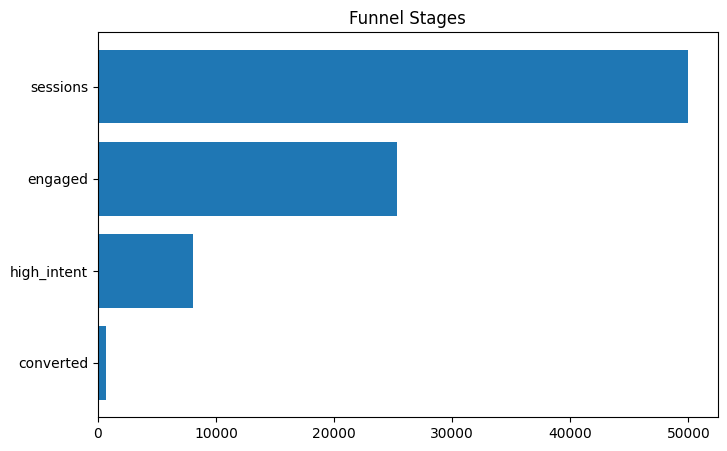

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(funnel_df['stage'], funnel_df['count'])
plt.title("Funnel Stages")
plt.gca().invert_yaxis()
plt.show()

In [67]:
df_cleaned.groupby('device_deviceCategory').apply(
    lambda x: (x['converted'].sum() / len(x))
)

device_deviceCategory
desktop    0.016181
mobile     0.004420
tablet     0.004245
dtype: float64

In [68]:
df_cleaned.groupby('totals_pageviews')['converted'].mean().head(20)

totals_pageviews
1.0     0.000000
2.0     0.000000
3.0     0.000236
4.0     0.000000
5.0     0.000557
6.0     0.000000
7.0     0.003055
8.0     0.003802
9.0     0.010029
10.0    0.023636
11.0    0.073826
12.0    0.061798
13.0    0.089404
14.0    0.091837
15.0    0.090517
16.0    0.167401
17.0    0.147959
18.0    0.142857
19.0    0.177305
20.0    0.184874
Name: converted, dtype: float64

In [69]:
df_cleaned['engagement_level'] = pd.cut(
    df_cleaned['totals_pageviews'],
    bins=[0, 1, 3, 10, 1000],
    labels=['1_page', 'low', 'medium', 'high']
)

df_cleaned.groupby('engagement_level')['converted'].mean()

engagement_level
1_page    0.000000
low       0.000077
medium    0.003140
high      0.168743
Name: converted, dtype: float64

In [70]:
df_cleaned.groupby('engagement_level')['converted'].mean()

engagement_level
1_page    0.000000
low       0.000077
medium    0.003140
high      0.168743
Name: converted, dtype: float64

<Axes: xlabel='engagement_level'>

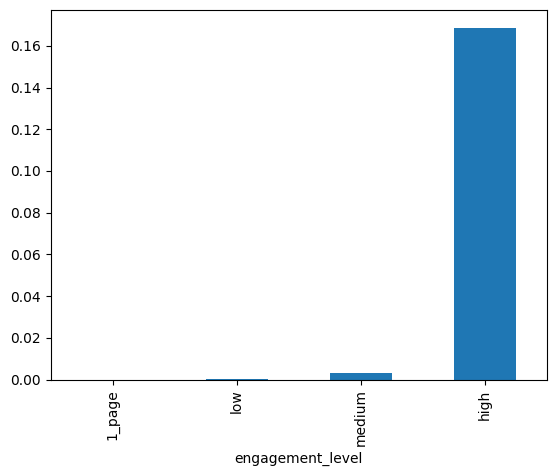

In [71]:
df_cleaned.groupby('engagement_level')['converted'].mean().plot(kind='bar')

Revenue per channel

In [72]:
channel_rev = df_cleaned.groupby('channelGrouping').agg({
    'totals_transactionRevenue': 'sum',
    'fullVisitorId': 'count',
    'converted': 'mean'
}).rename(columns={
    'totals_transactionRevenue': 'revenue',
    'fullVisitorId': 'traffic',
    'converted': 'conversion_rate'
})

channel_rev['revenue_per_session'] = (
    channel_rev['revenue'] / channel_rev['traffic']
)

channel_rev['traffic_share'] = channel_rev['traffic'] / len(df_cleaned)
channel_rev['revenue_share'] = (
    channel_rev['revenue'] / channel_rev['revenue'].sum()
)

channel_rev.sort_values('revenue', ascending=False)

,revenue,traffic,conversion_rate,revenue_per_session,traffic_share,revenue_share
channelGrouping,,,,,,
Referral,4.298234e+10,5960,0.054866,7.211802e+06,0.11920,0.516121
Direct,2.117642e+10,7899,0.015192,2.680899e+06,0.15798,0.254281
Organic Search,1.550109e+10,20877,0.007903,7.424960e+05,0.41754,0.186133
Display,2.284820e+09,389,0.023136,5.873573e+06,0.00778,0.027436
Paid Search,1.037240e+09,1554,0.014157,6.674646e+05,0.03108,0.012455
Social,2.975900e+08,12480,0.000641,2.384535e+04,0.24960,0.003573
(Other),0.000000e+00,1,0.000000,0.000000e+00,0.00002,0.000000
Affiliates,0.000000e+00,840,0.000000,0.000000e+00,0.01680,0.000000


<Axes: title={'center': 'Revenue by Channel'}, ylabel='channelGrouping'>

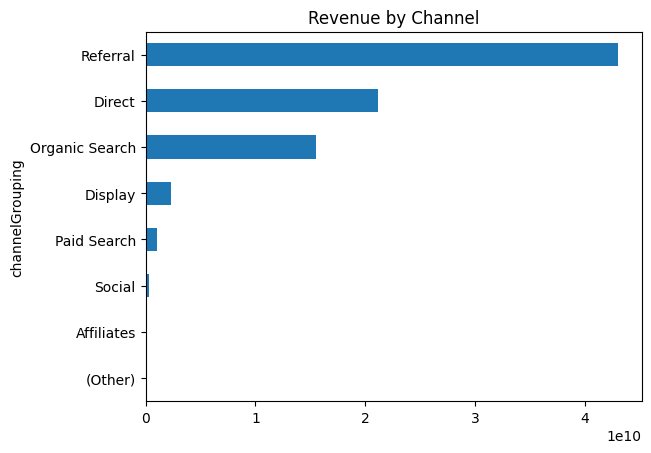

In [73]:
channel_rev['revenue'].sort_values().plot(
    kind='barh',
    title='Revenue by Channel'
)

<Axes: title={'center': 'Revenue per Session by Channel'}, ylabel='channelGrouping'>

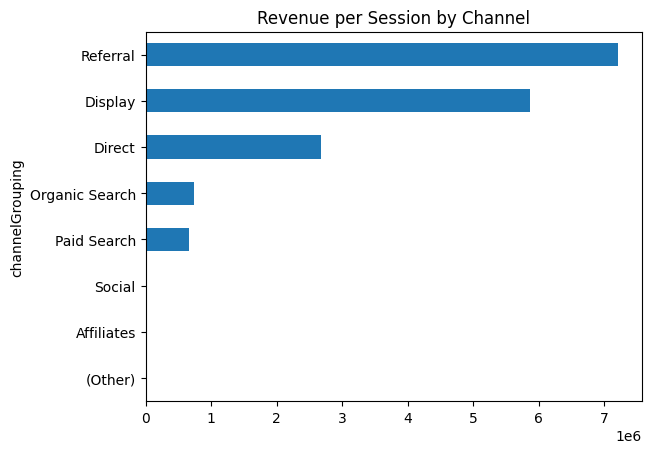

In [74]:
channel_rev.sort_values('revenue_per_session')['revenue_per_session'].plot(
    kind='barh',
    title='Revenue per Session by Channel'
)

High-value user analysis (VIP customers)

repeat buyers?

single high-ticket buyers?

In [75]:
user_df = df_cleaned.groupby('fullVisitorId').agg({
    'totals_transactionRevenue': 'sum',
    'visitId': 'nunique',
    'converted': 'sum'
}).rename(columns={
    'totals_transactionRevenue': 'total_revenue',
    'visitId': 'num_sessions',
    'converted': 'num_conversions'
})

user_df.head()

,total_revenue,num_sessions,num_conversions
fullVisitorId,,,
0000174067426171406,0.0,1,0
0000245437374675368,0.0,1,0
0000750929315523353,0.0,1,0
0001156383977201253,0.0,1,0
0001213046045394417,0.0,1,0


In [76]:
threshold = user_df['total_revenue'].quantile(0.95)

user_df['is_vip'] = (user_df['total_revenue'] >= threshold).astype(int)

In [77]:
user_df['is_repeat_buyer'] = (user_df['num_conversions'] > 1).astype(int)

In [78]:
user_df['is_single_high_value'] = (
    (user_df['num_conversions'] == 1) &
    (user_df['total_revenue'] > threshold)
).astype(int)

In [79]:
summary = {
    "total_users": len(user_df),
    "vip_users": user_df['is_vip'].sum(),
    "repeat_buyers": user_df['is_repeat_buyer'].sum(),
    "single_high_value": user_df['is_single_high_value'].sum()
}

summary

{'total_users': 45416,
 'vip_users': np.int64(45416),
 'repeat_buyers': np.int64(16),
 'single_high_value': np.int64(618)}

In [80]:
vip_revenue_share = (
    user_df[user_df['is_vip'] == 1]['total_revenue'].sum() /
    user_df['total_revenue'].sum()
)

print("VIP revenue share:", vip_revenue_share)

VIP revenue share: 1.0


In [81]:
user_df.groupby('is_repeat_buyer')['total_revenue'].mean()

is_repeat_buyer
0    1.546248e+06
1    8.174912e+08
Name: total_revenue, dtype: float64

In [82]:
user_df.groupby('is_single_high_value')['total_revenue'].mean()

is_single_high_value
0    2.919742e+05
1    1.135917e+08
Name: total_revenue, dtype: float64

In [83]:
user_df['avg_revenue_per_session'] = (
    user_df['total_revenue'] / user_df['num_sessions']
)

Correlation insights

In [84]:
cols = [
    'totals_pageviews',
    'totals_hits',
    'num_sessions_per_user',
    'totals_transactionRevenue',
    'converted'
]

corr = df_cleaned[cols].corr()
corr

,totals_pageviews,totals_hits,num_sessions_per_user,totals_transactionRevenue,converted
totals_pageviews,1.000000,0.984399,0.078005,0.212914,0.414394
totals_hits,0.984399,1.000000,0.076549,0.207532,0.391490
num_sessions_per_user,0.078005,0.076549,1.000000,0.041349,0.046868
totals_transactionRevenue,0.212914,0.207532,0.041349,1.000000,0.399166
converted,0.414394,0.391490,0.046868,0.399166,1.000000


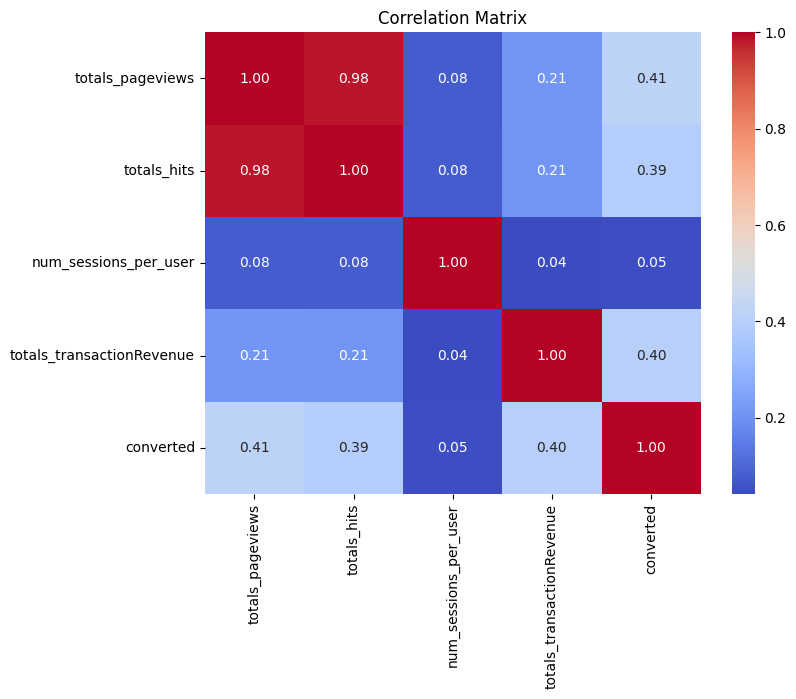

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [86]:
df_cleaned['log_revenue'] = np.log1p(df_cleaned['totals_transactionRevenue'])

corr = df_cleaned[['log_revenue','totals_pageviews','totals_hits']].corr()

In [87]:
df_cleaned[cols].corr()['converted'].sort_values(ascending=False)

converted                    1.000000
totals_pageviews             0.414394
totals_transactionRevenue    0.399166
totals_hits                  0.391490
num_sessions_per_user        0.046868
Name: converted, dtype: float64

In [88]:
df_conv = df_cleaned[df_cleaned['converted'] == 1]

df_conv[['totals_pageviews','totals_hits','totals_transactionRevenue']].corr()

,totals_pageviews,totals_hits,totals_transactionRevenue
totals_pageviews,1.000000,0.974117,0.165164
totals_hits,0.974117,1.000000,0.159862
totals_transactionRevenue,0.165164,0.159862,1.000000


<Axes: xlabel='converted', ylabel='totals_pageviews'>

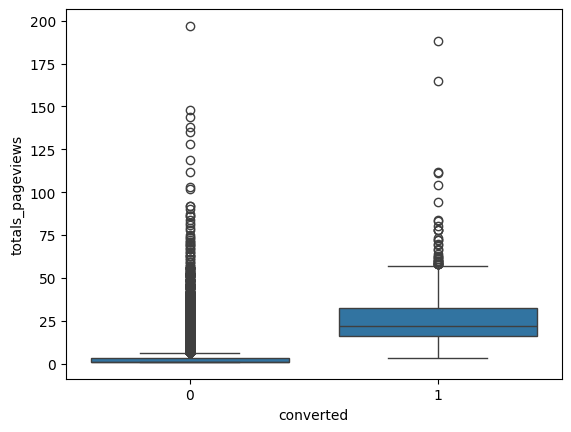

In [89]:
sns.boxplot(x='converted', y='totals_pageviews', data=df_cleaned)

In [90]:

path = input("Enter output file path (e.g. outputs/data.xlsx): ")

save_to_excel(df_cleaned, path)

💾 Saved cleaned data to outputs/analysed_data.xlsx
